<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Discovered Network Weights ---
w0: 1.266066 (Theoretical ideal: 1.250000)
w1: 1.130318 (Theoretical ideal: 1.125000)
w2: 0.271495 (Theoretical ideal: 0.250000)
w3: 0.044337 (Theoretical ideal: 0.041666)

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 1.1102e-16     
0.100 | 1.105171     | 1.105171        | 9.2421e-15     
0.200 | 1.221403     | 1.221403        | 9.6351e-15     
0.300 | 1.349859     | 1.349859        | 7.5668e-15     
0.400 | 1.491825     | 1.491825        | 3.5722e-15     
0.500 | 1.648721     | 1.648721        | 1.6161e-15     
0.600 | 1.822119     | 1.822119        | 2.4372e-15     
0.700 | 2.013753     | 2.013753        | 3.7490e-15     
0.800 | 2.225541     | 2.225541        | 1.7959e-15     
0.900 | 2.459603     | 2.459603        | 1.4444e-15     
1.000 | 2.718282     | 2.718282        | 8.1686e-16     


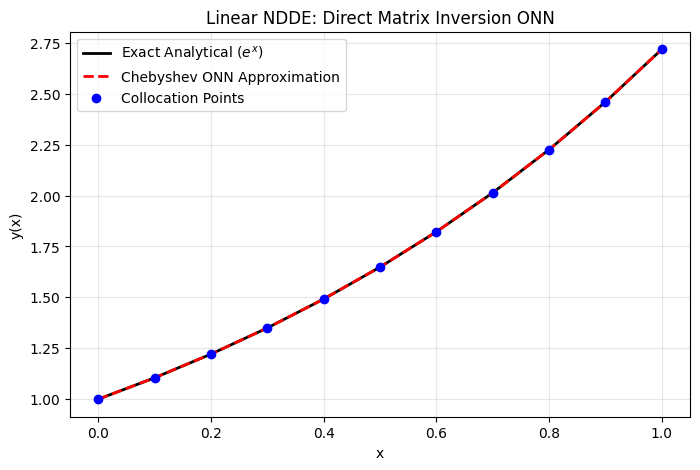

In [18]:
#Problem-1(Chebyshev)
import torch
import matplotlib.pyplot as plt

# ==========================================
#  Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]
        T_d[:, n] = 2 * T[:, n-1] + 2 * x * T_d[:, n-1] - T_d[:, n-2]

    return T, T_d

# ==========================================
#  Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_chebyshev_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # Evaluate basis at current, delayed, and transformed arguments
    T_x, Td_x = get_chebyshev_basis(x, N_POLYS)
    _, Td_sqrt_x = get_chebyshev_basis(torch.sqrt(x), N_POLYS)
    T_sin_x, _ = get_chebyshev_basis(torch.sin(x), N_POLYS)

    # Pre-compute equation coefficients for LHS
    sqrt_cos_x = torch.sqrt(torch.cos(x))
    sin_sqrt_x = torch.sin(torch.sqrt(x))
    exp_x = torch.exp(x)

    # LHS: Sum( w_n * [T'_n(x) + sqrt(cos(x))T'_n(sqrt(x)) + (sin(sqrt(x)) + e^x)T_n(sin(x))] )
    coeffs = Td_x + sqrt_cos_x * Td_sqrt_x + (sin_sqrt_x + exp_x) * T_sin_x
    A[i+1, :] = coeffs

    # RHS: e^x + sqrt(cos(x))e^(sqrt(x)) + (sin(sqrt(x)) + e^x)e^(sin(x))
    rhs = exp_x + sqrt_cos_x * torch.exp(torch.sqrt(x)) + (sin_sqrt_x + exp_x) * torch.exp(torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Because the ODE is linear, we can use torch.linalg.solve to find exact analytical weights

weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f} (Theoretical ideal: 1.250000)")
print(f"w1: {weights[1].item():.6f} (Theoretical ideal: 1.125000)")
print(f"w2: {weights[2].item():.6f} (Theoretical ideal: 0.250000)")
print(f"w3: {weights[3].item():.6f} (Theoretical ideal: 0.041666)")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_chebyshev_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Discovered Probabilistic Hermite Weights ---
w0: 1.648647 (Theoretical derived: 1.7818)
w1: 1.648938 (Theoretical derived: 1.0000)
w2: 0.823973 (Theoretical derived: 0.7818)

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.100 | 1.105171     | 1.105171        | 8.8402e-15     
0.200 | 1.221403     | 1.221403        | 9.2715e-15     
0.300 | 1.349859     | 1.349859        | 7.8957e-15     
0.400 | 1.491825     | 1.491825        | 3.2745e-15     
0.500 | 1.648721     | 1.648721        | 1.6161e-15     
0.600 | 1.822119     | 1.822119        | 2.5591e-15     
0.700 | 2.013753     | 2.013753        | 3.7490e-15     
0.800 | 2.225541     | 2.225541        | 1.9954e-15     
0.900 | 2.459603     | 2.459603        | 1.6250e-15     
1.000 | 2.718282     | 2.718282        | 4.9011e-16     


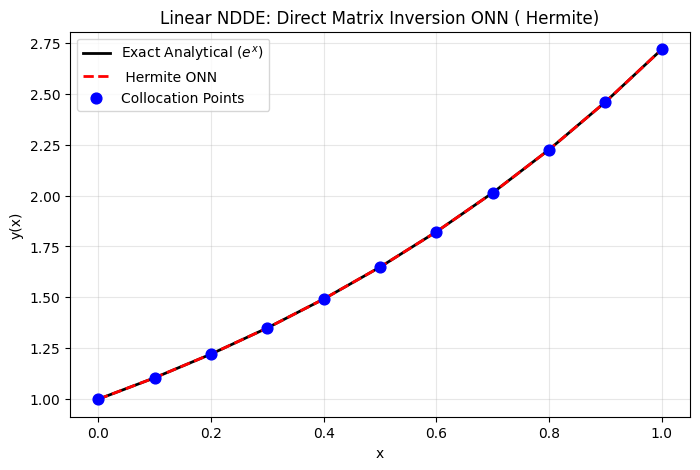

In [21]:
#Problem--1 (Hermite)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Probabilistic Hermite Basis Implementation
# ==========================================
def get_prob_hermite_basis(x, n_polys):
    """
    Generates Probabilistic Hermite polynomials He_n(x) and their derivatives He'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    He = torch.zeros(num_points, n_polys, dtype=torch.float64)
    He_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> He_0 = 1, He'_0 = 0
    He[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> He_1 = x, He'_1 = 1
        He[:, 1] = x
        He_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        # He_n(x) = x * He_{n-1}(x) - (n-1) * He_{n-2}(x)
        He[:, n] = x * He[:, n-1] - (n - 1.0) * He[:, n-2]

        # He'_n(x) = n * He_{n-1}(x)
        He_d[:, n] = float(n) * He[:, n-1]

    return He, He_d

# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,   dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
He_0, _ = get_prob_hermite_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = He_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # Evaluate basis at current, delayed, and transformed arguments
    He_x, Hed_x = get_prob_hermite_basis(x, N_POLYS)
    _, Hed_sqrt_x = get_prob_hermite_basis(torch.sqrt(x), N_POLYS)
    He_sin_x, _ = get_prob_hermite_basis(torch.sin(x), N_POLYS)

    # Pre-compute equation coefficients for LHS
    sqrt_cos_x = torch.sqrt(torch.cos(x))
    sin_sqrt_x = torch.sin(torch.sqrt(x))
    exp_x = torch.exp(x)

    # LHS: Sum( w_n * [He'_n(x) + sqrt(cos(x))He'_n(sqrt(x)) + (sin(sqrt(x)) + e^x)He_n(sin(x))] )
    coeffs = Hed_x + sqrt_cos_x * Hed_sqrt_x + (sin_sqrt_x + exp_x) * He_sin_x
    A[i+1, :] = coeffs

    # RHS: e^x + sqrt(cos(x))e^(sqrt(x)) + (sin(sqrt(x)) + e^x)e^(sin(x))
    rhs = exp_x + sqrt_cos_x * torch.exp(torch.sqrt(x)) + (sin_sqrt_x + exp_x) * torch.exp(torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Using torch.linalg.solve for exact analytical weights on the perfectly determined square matrix
weights = torch.linalg.solve(A, b)

print("--- Discovered Probabilistic Hermite Weights ---")
print(f"w0: {weights[0].item():.6f} (Theoretical derived: 1.7818)")
print(f"w1: {weights[1].item():.6f} (Theoretical derived: 1.0000)")
print(f"w2: {weights[2].item():.6f} (Theoretical derived: 0.7818)")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
He_eval, _ = get_prob_hermite_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (He_eval @ weights).flatten()
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label=' Hermite ONN ')
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN ( Hermite)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Discovered Legendre Network Weights ---
w0: 1.175201
w1: 1.103638
w2: 0.357814

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 2.2204e-16     
0.100 | 1.105171     | 1.105171        | 1.0046e-14     
0.200 | 1.221403     | 1.221403        | 1.0181e-14     
0.300 | 1.349859     | 1.349859        | 7.4023e-15     
0.400 | 1.491825     | 1.491825        | 2.8280e-15     
0.500 | 1.648721     | 1.648721        | 1.6161e-15     
0.600 | 1.822119     | 1.822119        | 3.0465e-15     
0.700 | 2.013753     | 2.013753        | 3.9695e-15     
0.800 | 2.225541     | 2.225541        | 1.7959e-15     
0.900 | 2.459603     | 2.459603        | 1.6250e-15     
1.000 | 2.718282     | 2.718282        | 3.2674e-16     


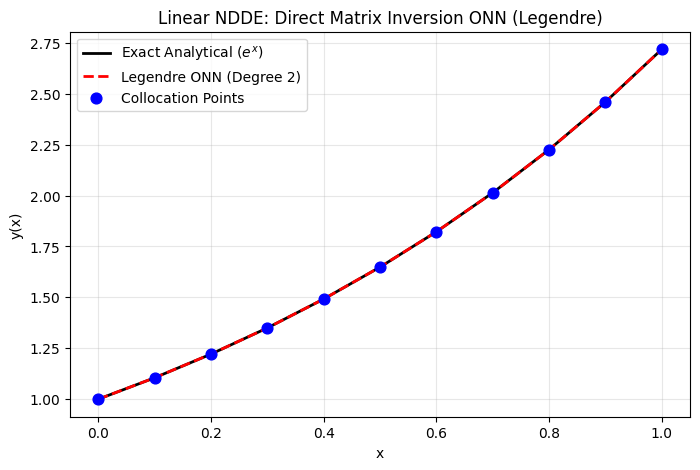

In [24]:
#Problem--1(Legendre)
import torch
import matplotlib.pyplot as plt

# ==========================================
#  Legendre Basis Implementation
# ==========================================
def get_legendre_basis(x, n_polys):
    """
    Generates Legendre polynomials P_n(x) and their derivatives P'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    P = torch.zeros(num_points, n_polys, dtype=torch.float64)
    P_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> P_0 = 1, P'_0 = 0
    P[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> P_1 = x, P'_1 = 1
        P[:, 1] = x
        P_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        P[:, n] = ((2.0 * n - 1.0) * x * P[:, n-1] - (n - 1.0) * P[:, n-2]) / n
        P_d[:, n] = ((2.0 * n - 1.0) * (P[:, n-1] + x * P_d[:, n-1]) - (n - 1.0) * P_d[:, n-2]) / n

    return P, P_d

# ==========================================
#  Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
P_0, _ = get_legendre_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = P_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # Evaluate basis at current, delayed, and transformed arguments
    P_x, Pd_x = get_legendre_basis(x, N_POLYS)
    _, Pd_sqrt_x = get_legendre_basis(torch.sqrt(x), N_POLYS)
    P_sin_x, _ = get_legendre_basis(torch.sin(x), N_POLYS)

    # Pre-compute equation coefficients for LHS
    sqrt_cos_x = torch.sqrt(torch.cos(x))
    sin_sqrt_x = torch.sin(torch.sqrt(x))
    exp_x = torch.exp(x)

    # LHS: Sum( w_n * [P'_n(x) + sqrt(cos(x))P'_n(sqrt(x)) + (sin(sqrt(x)) + e^x)P_n(sin(x))] )
    coeffs = Pd_x + sqrt_cos_x * Pd_sqrt_x + (sin_sqrt_x + exp_x) * P_sin_x
    A[i+1, :] = coeffs

    # RHS: e^x + sqrt(cos(x))e^(sqrt(x)) + (sin(sqrt(x)) + e^x)e^(sin(x))
    rhs = exp_x + sqrt_cos_x * torch.exp(torch.sqrt(x)) + (sin_sqrt_x + exp_x) * torch.exp(torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# . Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Using torch.linalg.solve for exact analytical weights on the square matrix

weights = torch.linalg.solve(A, b)

print("--- Discovered Legendre Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")

# ==========================================
# . Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
P_eval, _ = get_legendre_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (P_eval @ weights).flatten()
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Legendre ONN (Degree 2)')
plt.scatter(points_colloc.numpy(), (get_legendre_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN (Legendre)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()